# **Strategi Bisnis Menggunakan Data Waktu Penggunaan Internet & Usia Berbasis Algoritma**

## Library

In [ ]:
# Import Library Pandas untuk membaca dataset CSV.

import pandas as pd

## Dataset Input - Output & Path

In [ ]:
# Memberi Path/Jalan ke File dataset CSV agar terbaca.

path = "/content/drive/MyDrive/Dataset AVD SMT 2 /daily_internet_usage_by_age_group.csv"

baca_csv = pd.read_csv(path)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Dataset AVD SMT 2 /daily_internet_usage_by_age_group.csv'

In [ ]:
# Membaca file dataset CSV (ibarat print).

baca_csv

# Business Understanding / Pemahaman Bisnis


## 1. **Business Objective / Tujuan Bisnis**

1. Tujuan Bisnis: Meningkatkan penetrasi pasar dengan menawarkan solusi algoritma yang tepat untuk segmen usia tertentu.
2. Kriteria Kesuksesan: Peningkatan adopsi produk sebesar X%/Persenan pada segmen target dalam waktu ? bulan/bulan yang ditentukan.

Pertanyaan Bisnis yang Digunakan:
1. Kelompok usia mana yang memiliki kebutuhan digital paling tidak terpenuhi?
2. Faktor apa (perangkat, jenis internet, pola penggunaan) yang paling memengaruhi pengalaman pengguna?
3. Bagaimana algoritma dapat dioptimalkan untuk setiap segmen?

## **2. Asses Situation**

Inventarisasi Sumber Daya:

* Data: Dataset dengan 2800 entri, mencakup variabel: 'user_id, date, age, age_group, social_media_hours, work_or_study_hours, entertainment_hours, total_screen_time, primary_device, internet_type'.

* Alat Analitik: Tools untuk analisis data seperti Python (Pandas, Scikit-learn), R, atau platform analisis visual seperti Tableau.
* Keahlian: Tim data scientist atau analis data yang mampu melakukan analisis eksplorasi, statistik, dan pemodelan.

* Pemangku Kepentingan: Manajer produk, tim pemasaran, pengembang algoritma, dan tim strategi bisnis.

Kerangka konseptual ini dapat membantu mengeksplorasi masalah bisnis dan mengembangkan hubungan antara berbagai variabel hingga kesimpulan dan rencana implementasi kedepannya.

## 3. **Analytic Goals & Projek Plan**

Berdasarkan tujuan bisnis, tujuan analitik dirumuskan sebagai berikut:

1. Peluang Perusahaan: Membuka peluang untuk perusahaan dalam memasarkan produk dengan waktu yang tepat mengikuti perkembangan tren dan alur sosial media seperti Tiktok, Instagram, DLL.
2. Prediksi: Mengembangkan model untuk memprediksi kelompok usia atau preferensi perangkat berdasarkan pola penggunaan.
3. Rekomendasi Strategi: Memberikan rekomendasi spesifik untuk penargetan algoritma dan personalisasi konten untuk setiap kalangan.

Namun hal-hal diatas tidak hanya berlaku untuk perusahaan, melainkan pemerintah atau orang yang memiliki kuasa atas social media, mereka bisa menggunakan algoritma untuk kepentingan sesuatu... It could be bad or good, (Opini Pribadi).

Projek Plan untuk bisnis:

### Fase 1: Persiapan dan Pemahaman Data

* Mengumpulkan dan memvalidasi data.
* Melakukan eksplorasi data awal (EDA) untuk memahami distribusi, missing values, dan outliers.
* Mendefinisikan metrik evaluasi yang sejalan dengan kriteria kesuksesan bisnis.

### Fase 2: Analisis Eksploratori dan Segmentasi

* Analisis statistik deskriptif untuk setiap kelompok usia.
Visualisasi pola penggunaan (misalnya, rata-rata waktu layar per aktivitas per kelompok usia).
* Melakukan analisis klaster (clustering) untuk mengidentifikasi segmen pengguna yang homogen di dalam atau antar kelompok usia.

### Fase 3: Pemodelan dan Analisis Lanjutan

* Mengembangkan model klasifikasi untuk memprediksi kelompok usia berdasarkan variabel penggunaan.
* Uji statistik untuk memvalidasi perbedaan signifikan antar kelompok.




# **Studi Kasus 2 AVD 😏**

## Library

In [ ]:
# Import Library Pandas untuk membaca dataset CSV.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

## Memuat Dataset

In [ ]:
path = "/content/drive/MyDrive/Dataset AVD SMT 2 /C_PrimatechService.csv"

df = pd.read_csv(path)

df

## 1. Tampilkan Statistik Deskriptif dataset menjelaskan insight terkait kelengkapan data yang bisa di peroleh dari baris 'count"

In [ ]:
df.describe(include='all')


**Insight**

1. Penentuan Basis Data (Baseline)
Mayoritas kolom menunjukkan angka 214. Ini mengindikasikan bahwa dataset Anda memiliki total 214 baris (records). Kolom seperti service_id, tanggal, provinsi, hingga status_servis semuanya terisi penuh (100% lengkap).

2. Identifikasi Data yang Hilang (Missing Values) Ada dua kolom yang memiliki jumlah count di bawah 214, yang berarti terdapat Missing Values (data kosong/NaN):

* durasi_servis_per_jam (148):
* Terdapat 66 data yang hilang ($214 - 148 = 66$).
Ini adalah defisit yang cukup signifikan (sekitar 30,8% data hilang).

Insight: Anda perlu mengecek apakah layanan tertentu memang tidak dicatat durasinya, atau ada kegagalan input pada sistem. Jika ingin melakukan analisis rata-rata durasi, data yang hilang ini bisa membiaskan hasil.

* rating_pelanggan (202):
* Terdapat 12 data yang hilang ($214 - 202 = 12$).

Insight: Ini hal yang wajar dalam bisnis jasa, karena tidak semua pelanggan bersedia memberikan rating setelah servis selesai. Tingkat kelengkapannya masih cukup tinggi (sekitar 94%).

## 2. Korelasi total_pendapatan & biaya_servis_per_unit

In [ ]:
plt.figure(figsize=(6, 8))
sns.heatmap(data=df[['total_pendapatan', 'biaya_servis_per_unit']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Total Pendapatan dan Biaya Servis Per Unit')
plt.show()

## 3. Pengecekan duplicated values & missing values

In [ ]:
# Duplicated Values

df[df.duplicated()]

In [ ]:
#Missing Values

pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

**Informasi yang diperoleh:**

Dataset ini dalam kondisi kurang bersih (dirty data).

* Validasi Perhitungan: Perlu dilakukan pengisian (imputation) pada durasi_servis_per_jam jika ingin menganalisis produktivitas.

* Pembersihan: Wajib menghapus 14 baris terakhir agar tidak terjadi penghitungan ganda (double counting).

* Standardisasi: Selain nilai yang hilang/duplikat, ditemukan masalah format pada kolom tanggal (bercampur antara format YYYY-MM-DD, DD/MM/YYYY, dan nama bulan) serta inkonsistensi huruf kapital pada kolom provinsi dan jenis_servis yang perlu diseragamkan.

## 4. Visualisasi tren terhadap total penjualan dalam 1 bulan terakhir

In [ ]:

start_date = df.index.max() - pd.DateOffset(years=1)
df_last_year = df.loc[df.index >= start_date].copy()

penjualan_bulanan = df_last_year['total_pendapatan'].resample('ME').sum()

plt.figure(figsize=(12, 6))
penjualan_bulanan.plot(marker='o', linestyle='-', color='skyblue')
plt.title("Trend Total Penjualan 1 Tahun Terakhir", fontsize=16)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Penjualan", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight:

Analisis ini memungkinkan untuk melakukan Peramalan (Forecasting) sederhana. Jika melihat pendapatan selalu naik di bulan Juni (berdasarkan data 2024 di dataset), harusnya dapat mempersiapkan teknisi lebih banyak di bulan Juni tahun berikutnya untuk menghindari missing values pada durasi servis akibat beban kerja yang terlalu tinggi.

## 5. Menyimpan dataset ke file xlsx

In [ ]:
df.to_excel('PrimatechService.xlsx', index=False)

# **Checkpoint 2: Data Understanding & EDA**

### Library

In [ ]:
# Import Library Pandas untuk membaca dataset CSV.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

### Memuat Dataset

Dataset ini berisi catatan penggunaan internet harian sintetis yang dikelompokkan berdasarkan berbagai kelompok usia. Dataset ini menangkap bagaimana pengguna mengalokasikan waktu online mereka di antara media sosial, pekerjaan atau studi, dan aktivitas hiburan. Selain itu, dataset ini mencakup informasi tentang perangkat utama yang digunakan dan jenis koneksi internet.

In [ ]:
# Memberi Path/Jalan ke File dataset CSV agar terbaca.

path = "/content/drive/MyDrive/Dataset AVD SMT 2 /daily_internet_usage_by_age_group.csv"

df = pd.read_csv(path)

df

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi


## **Data Understanding**

### Struktur Data (Informasi Lanjutan)

In [ ]:
df.info()

1. user_id:
Jumlah baris: 2800
Tipe data: int64
Deskripsi: ID unik pengguna

2. date:
Jumlah baris: 2800
Tipe data: object
Deskripsi: Tanggal pencatatan data

3. age:
Jumlah baris: 2800
Tipe data: int64
Deskripsi: Usia pengguna dalam tahun

4. age_group:
Jumlah baris: 2800
Tipe data: object
Deskripsi: Kelompok usia pengguna (kategorikal)

5. social_media_hours:
Jumlah baris: 2800
Tipe data: float64
Deskripsi: Jumlah jam penggunaan media sosial

6. work_or_study_hours:
Jumlah baris: 2800
Tipe data: float64
Deskripsi: Jumlah jam untuk pekerjaan atau studi

7. entertainment_hours:
Jumlah baris: 2800
Tipe data: float64
Deskripsi: Jumlah jam untuk hiburan

8. total_screen_time:
Jumlah baris: 2800
Tipe data: float64
Deskripsi: Total waktu layar (mungkin jumlah dari kolom 5-7)

9. primary_device:
Jumlah baris: 2800
Tipe data: object
Deskripsi: Perangkat utama yang digunakan (misal: smartphone, laptop)

10. internet_type:
Jumlah baris: 2800
Tipe data: object
Deskripsi: Jenis koneksi internet (misal: WiFi, mobile data)

### Statistik Deskriptif

In [ ]:
df.describe(include='all')

Daftar Kolom dan Deskripsi Data
User ID: Jumlah baris: 2800 | Tipe data: int64 | Deskripsi: ID unik untuk setiap pengguna.

Date: Jumlah baris: 2800 | Tipe data: object | Deskripsi: Tanggal pengambilan data atau aktivitas.

Age: Jumlah baris: 2800 | Tipe data: int64 | Deskripsi: Usia pengguna dalam angka.

Age Group: Jumlah baris: 2800 | Tipe data: object | Deskripsi: Kategori kelompok usia (contoh: 26-35).

Social Media Hours: Jumlah baris: 2800 | Tipe data: float64 | Deskripsi: Durasi penggunaan media sosial dalam jam.

Work or Study Hours: Jumlah baris: 2800 | Tipe data: float64 | Deskripsi: Durasi waktu untuk bekerja atau belajar dalam jam.

Entertainment Hours: Jumlah baris: 2800 | Tipe data: float64 | Deskripsi: Durasi waktu untuk hiburan dalam jam.

Total Screen Time: Jumlah baris: 2800 | Tipe data: float64 | Deskripsi: Akumulasi total waktu di depan layar dalam jam.

Primary Device: Jumlah baris: 2800 | Tipe data: object | Deskripsi: Perangkat utama yang digunakan.

Internet Type: Jumlah baris: 2800 | Tipe data: object | Deskripsi: Jenis koneksi internet yang digunakan.

---

1. Analisis demografi (usia)
* Rentang Usia: Pengguna dalam dataset ini memiliki usia antara 13 hingga 75 tahun.
* Rata-rata Usia: Rata-rata (μ) pengguna berusia sekitar 38.4 tahun.
* Kelompok Dominan: Kelompok usia 26-35 adalah yang paling sering muncul (frekuensi 493).
* Median: Nilai tengah usia berada pada 35 tahun.

2. Analisis penggunaan waktu
* Perangkat Terpopuler: Tablet adalah perangkat utama yang paling banyak digunakan oleh 949 orang.
* Koneksi Internet: Mayoritas pengguna (1.408 orang) menggunakan WiFi dibandingkan data seluler.
* Hari Tersibuk: Tanggal 2024-09-04 memiliki jumlah entri data terbanyak yaitu 17 aktivitas dalam satu hari.

3. Perangkat & internet
* Perangkat Terpopuler: Tablet adalah perangkat utama yang paling banyak digunakan oleh 949 orang.
* Koneksi Internet: Mayoritas pengguna (1.408 orang) menggunakan WiFi dibandingkan data seluler.
* Hari Tersibuk: Tanggal 2024-09-04 memiliki jumlah entri data terbanyak yaitu 17 aktivitas dalam satu hari.


### Data Type Check

In [ ]:
df.dtypes

Data type check (pemeriksaan tipe data) adalah proses verifikasi dalam pemrograman untuk memastikan bahwa variabel, parameter, atau input data sesuai dengan jenis yang diharapkan.

Kolom date menggunakan tipe data object bukan date. Sisa tipe data sesuai kebanyakan menggunakan interger dan float. Mengapa age_group menggunakan objectV dikarenakan menggunakan jarak umur seperti (18-25) Dan lain-lain.


### Incosistent Values

1. **"user_id"**

Data di kolom user_id tidak ada yang incosistent.

In [ ]:
print(df['user_id'].unique())

2. **"date"**

Data di kolom date tidak ada yang incosistent.

In [ ]:
print(df['date'].unique())

3. **"age"**

Data di kolom age tidak ada yang incosistent.

In [ ]:
print(df['age'].unique())

4. **"age_group"**

Data di kolom age_group tidak ada yang incosistent, terkecuali 60+ yang dimaksud berumur lebih dari 60.

In [ ]:
print(df['age_group'].unique())

5. **"social_media_hours"**

Data di kolom social_media_hours masih kurang tepat, bisa saja menggunakan 3.0 / 2.0 / 4.0 untuk memberi detail waktu walau tidak lebih dari hitungan jam.

In [ ]:
print(df['social_media_hours'].unique())

6. **"work_or_study_hours"**

Data di kolom work_or_study_hours masih kurang tepat, bisa saja menggunakan 3.0 / 2.0 / 4.0 untuk memberi detail waktu walau tidak lebih dari hitungan jam.

In [ ]:
print(df['work_or_study_hours'].unique())

7. **"entertainment_hours"**

Data di kolom work_or_study_hours masih kurang tepat, bisa saja menggunakan 1.0 / 3.0 untuk memberi detail waktu walau tidak lebih dari hitungan jam.

In [ ]:
print(df['entertainment_hours'].unique())

8. **"total_screen_time"**

Data di kolom work_or_study_hours masih kurang tepat, bisa saja menggunakan 2.0 / 3.0 / 7.0 Dll. untuk memberi detail waktu walau tidak lebih dari hitungan jam.

In [ ]:
print(df['total_screen_time'].unique())

9. **"primary_device"**

Data di kolom primary_device tidak ada yang incosistent.

In [ ]:
print(df['primary_device'].unique())

10. **"internet_type"**

Data di kolom internet_type tidak ada yang incosistent.

In [ ]:
print(df['internet_type'].unique())

### Missing Values

Tidak ada data yang hilang pada semua kolom dataset ini.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
user_id,0.0
date,0.0
age,0.0
age_group,0.0
social_media_hours,0.0
work_or_study_hours,0.0
entertainment_hours,0.0
total_screen_time,0.0
primary_device,0.0
internet_type,0.0


### Duplicated Values

In [ ]:
df[df.duplicated()]

Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani, namun jika ingin menangani anda dapat mengetikkan

df = df.drop_duplicates()

### Outliers

 Mengecek outliers bertujuan untuk membedakan antara "data yang salah (noise)" dan "data yang unik/berharga", lalu menanganinya dengan tepat (dihapus, diubah, atau dianalisis terpisah).

 Namun di outliers dataset ini tidak ada yang perlu ditangani.

 Lumayan bersih... yah datanya.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
user_id,0.0
age,0.0
social_media_hours,0.0
work_or_study_hours,0.0
entertainment_hours,0.0
total_screen_time,0.0


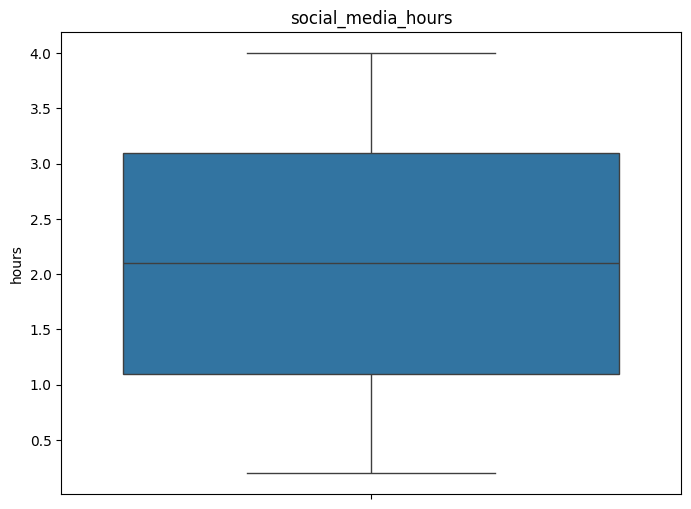

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['social_media_hours'])
plt.title('social_media_hours')
plt.ylabel('hours')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['total_screen_time'])
plt.title('total_screen_time')
plt.ylabel('screen time')
plt.show()

## **EDA**

## Comparison/Perbandingan

Aktivitas: Membandingkan umur dengan kelompok umur.

Tujuan: Untuk mengetahui waktu media sosial di kelompok umur tertentu untuk kebutuhan bisnis

Visualisasi: Bar Chart (Batang)

In [ ]:
sosmed_per_umur = df.groupby('age_group')['social_media_hours'].mean().sort_values(ascending=False)

# Membuat visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    x=sosmed_per_umur.index,
    y=sosmed_per_umur.values,
    palette='viridis',
    hue=sosmed_per_umur.index,
    legend=False
)
plt.title('Rata-rata Penggunaan Media Sosial Berdasarkan Kelompok Umur')
plt.xlabel('Kelompok Umur')
plt.ylabel('Rata-rata Jam (per hari)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Composition/Komposisi

Aktivitas: Melihat proporsi atau presentase kelompok umur dengan waktu social media

Tujuan: Untuk mengetahui kelompok umur mana yang paling sering aktif di social media, hal ini memberi keuntungan dalam bisnis.

Visualisasi: Bar Pie (Lingkaran Pie)

In [ ]:
sosmed_by_age = df.groupby('age_group')['social_media_hours'].sum().sort_values(ascending=False)

sosmed_by_age_top3 = sosmed_by_age.head(3)

plt.figure(figsize=(10, 8))
sosmed_by_age_top3.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title('Proporsi 3 Kelompok Umur Teratas dalam Penggunaan Media Sosial')
plt.ylabel('')
plt.axis('equal')
plt.show()

## Distribution (Distribusi)

Aktivitas: Menganalisis waktu penggunaan media social untuk melihat rata-rata.

Tujuan: Melihat penggunaan waktu social media dari rata-rata hingga yang terkecil dan untuk melihat kecendrungan.

Visualisasi: Histogram.

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['total_screen_time'], bins=20, kde=True)
plt.title('Waktu penggunaan internet')
plt.xlabel('Waktu')
plt.ylabel('Frekuensi')
plt.show()

## Relationship (Hubungan)

Aktivitas: Menganalisis korelasi antara waktu social media dengan waktu  entertainment.

Tujuan: Mengetahui apakah waktu social media di kalangan umur sejalan dengan waktu entertainment, hal ini menentukan keputusann perusahaan atau bisnis untuk menaruh algoritma.

Visualisasi: Heatmap

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['social_media_hours','entertainment_hours']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Kelompok umur dan waktu social media ')
plt.show()

# Studi Kasus 3 ✌

## Library

In [ ]:
# Import Library Pandas untuk membaca dataset CSV.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

## Memuat Dataset

In [ ]:
# Memberi Path/Jalan ke File dataset CSV agar terbaca.

path = "/content/drive/MyDrive/Dataset AVD SMT 2 /C_PrimatechService.csv"

df = pd.read_csv(path)

df

,service_id,tanggal,provinsi,jenis_servis,jumlah_unit_servis,biaya_servis_per_unit,durasi_servis_per_jam,total_pendapatan,status_servis,rating_pelanggan
0,SVC0001,2024-06-12,Jawa Tengah,Ac,4,156081.0,5.3,624324.0,dibatalkan,4.0
1,SVC0002,07 January 2024,Jawa Barat,LAPTOP,5,139045.0,5.1,695225.0,PROSES,5.0
2,SVC0003,03/03/2024,JAWA TENGAH,hp,3,5009758.0,2.8,15029274.0,DIBATALKAN,2.0
3,SVC0004,2024-02-05,DKI Jakarta,TV,5,160078.0,1.7,800390.0,dibatalkan,3.0
4,SVC0005,2024-06-22,DKI Jakarta,TV,5,392767.0,2.7,1963835.0,PROSES,3.0
...,...,...,...,...,...,...,...,...,...,...
209,SVC0046,12 April 2024,DKI JAKARTA,AC,1,423616.0,NaN,423616.0,PENDING,1.0
210,SVC0067,2024-06-23,JAWA BARAT,laptop,2,324327.0,1.9,648654.0,PENDING,2.0
211,SVC0183,25/06/2024,DKI Jakarta,laptop,1,417654.0,NaN,417654.0,Dibatalkan,1.0
212,SVC0166,04 February 2024,Jawa Timur,LAPTOP,2,86631.0,3.8,173262.0,Dibatalkan,5.0


## Data Preparation


### Missing Value

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

# before

,Null Ratio in %
service_id,0.000000
tanggal,0.000000
provinsi,0.000000
jenis_servis,0.000000
jumlah_unit_servis,0.000000
biaya_servis_per_unit,0.000000
durasi_servis_per_jam,30.841121
total_pendapatan,0.000000
status_servis,0.000000
rating_pelanggan,5.607477


In [ ]:
df['durasi_servis_per_jam'] = df['durasi_servis_per_jam'].fillna(df['durasi_servis_per_jam'].dropna().median())
df['rating_pelanggan'] = df['rating_pelanggan'].fillna(df['rating_pelanggan'].dropna().mean())

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

# after

,Null Ratio in %
service_id,0.0
tanggal,0.0
provinsi,0.0
jenis_servis,0.0
jumlah_unit_servis,0.0
biaya_servis_per_unit,0.0
durasi_servis_per_jam,0.0
total_pendapatan,0.0
status_servis,0.0
rating_pelanggan,0.0


Terlihat kolom durasi_servis_per_jam terdapat missing values sebesar 30% hal ini bisa di imputasi dengan median (nilai tengah) dan rating pelanggan terdapat missing values 5% di imputasikan juga dengan mean (nilai rata-rata), karena tidak ada outliers.

### Duplicated Value

In [ ]:
df = df.drop_duplicates()

In [ ]:
df[df.duplicated()]

#after

,service_id,tanggal,provinsi,jenis_servis,jumlah_unit_servis,biaya_servis_per_unit,durasi_servis_per_jam,total_pendapatan,status_servis,rating_pelanggan


Terdapat 13 baris dataset yang terduplicate, jadi diperbaiki dengan df.drop_duplicates

### Outliers

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

#before

Kolom,Persentase Outliers
jumlah_unit_servis,0.0
biaya_servis_per_unit,18.0
durasi_servis_per_jam,12.5
total_pendapatan,17.5
rating_pelanggan,0.0


In [ ]:
columns_to_impute = ["biaya_servis_per_unit", "durasi_servis_per_jam", "total_pendapatan"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

#after

Kolom,Persentase Outliers
jumlah_unit_servis,0.0
biaya_servis_per_unit,0.0
durasi_servis_per_jam,0.0
total_pendapatan,0.0
rating_pelanggan,0.0


### Incosistent Value

In [ ]:
print(df['tanggal'].unique())

['2024-06-12' '07 January 2024' '03/03/2024' '2024-02-05' '2024-06-22'
 '2024/05/31' '2024-01-09' '24/01/2024' '2024-02-29' '23/05/2024'
 '2024/06/15' '2024/02/26' '30 May 2024' '02/01/2024' '2024/06/27'
 '28 March 2024' '09/02/2024' '2024-03-27' '2024/01/24' '25 January 2024'
 '29 March 2024' '2024/01/12' '2024-05-17' '2024-04-06' '21 May 2024'
 '09 June 2024' '27/05/2024' '2024-06-29' '12/01/2024' '2024-03-15'
 '07 April 2024' '26 April 2024' '11 February 2024' '31/03/2024'
 '20 June 2024' '2024-06-28' '04/06/2024' '16/05/2024' '2024/02/11'
 '12/06/2024' '24 June 2024' '15/01/2024' '09 January 2024'
 '12 April 2024' '17/01/2024' '25 May 2024' '2024/02/24' '2024/04/11'
 '06 February 2024' '05/02/2024' '23 May 2024' '2024/05/29' '02/04/2024'
 '2024/02/05' '2024-01-24' '29/01/2024' '09/06/2024' '2024/06/23'
 '2024-06-01' '2024/04/08' '2024/06/01' '15 May 2024' '2024-05-21'
 '2024-06-23' '23 June 2024' '13 June 2024' '29 January 2024' '21/04/2024'
 '2024-04-26' '08/03/2024' '2024-05-09' 

In [ ]:
df["tanggal"] = pd.to_datetime(df["tanggal"], format="mixed")
df["tanggal"].head(5)

,tanggal
0,2024-06-12
1,2024-01-07
2,2024-03-03
3,2024-02-05
4,2024-06-22


Memperbaiki format datetime dari kolom tanggal.

In [ ]:
df['provinsi'] = df['provinsi'].str.upper()
df['jenis_servis'] = df['jenis_servis'].str.upper()
df['status_servis'] = df['status_servis'].str.upper()

print(df['provinsi'].unique())
print(df['jenis_servis'].unique())
print(df['status_servis'].unique())

['JAWA TENGAH' 'JAWA BARAT' 'DKI JAKARTA' 'JAWA TIMUR']
['AC' 'LAPTOP' 'HP' 'TV']
['DIBATALKAN' 'PROSES' 'SELESAI' 'PENDING']


Mengganti ketidaksamaan huruf di data, menggunakan str.upper.

## Data Construction & Data Reduction

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   service_id             214 non-null    object        
 1   tanggal                214 non-null    datetime64[ns]
 2   provinsi               214 non-null    object        
 3   jenis_servis           214 non-null    object        
 4   jumlah_unit_servis     214 non-null    int64         
 5   biaya_servis_per_unit  214 non-null    float64       
 6   durasi_servis_per_jam  148 non-null    float64       
 7   total_pendapatan       214 non-null    float64       
 8   status_servis          214 non-null    object        
 9   rating_pelanggan       202 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 16.8+ KB


Data Construction : Tidak selalu diperlukan jika fitur-fitur yang sudah ada (seperti 'age', 'social_media_hours', 'internet_type') sudah cukup informatif dan relevan untuk menjawab tujuan dataset.

Data Reduction : Untuk dataset Anda saat ini, jumlah entri dan kolom masih dalam batas wajar, sehingga tidak ada kebutuhan mendesak untuk mengurangi data atau dimensi. Selain itu, tidak ada indikasi adanya korelasi antar fitur yang sangat tinggi yang memerlukan pengurangan.

## Menyimpan dataset ke CSV

In [ ]:
df.to_csv('PrimatchService.csv', index=False)

# Checkpoint 3: Data Preparation (Data Cleaning, Construct Data, Data Reduction)

## Library

In [ ]:
# Import Library Pandas untuk membaca dataset CSV.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

## Memuat Dataset

Dataset ini berisi catatan penggunaan internet harian sintetis yang dikelompokkan berdasarkan berbagai kelompok usia. Dataset ini menangkap bagaimana pengguna mengalokasikan waktu online mereka di antara media sosial, pekerjaan atau studi, dan aktivitas hiburan. Selain itu, dataset ini mencakup informasi tentang perangkat utama yang digunakan dan jenis koneksi internet.

In [ ]:
# Memberi Path/Jalan ke File dataset CSV agar terbaca.

path = "/content/drive/MyDrive/Dataset AVD SMT 2 /daily_internet_usage_by_age_group.csv"

df = pd.read_csv(path)

df

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi
...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi


## Data Type Check


In [ ]:
df.dtypes

,0
user_id,int64
date,object
age,int64
age_group,object
social_media_hours,float64
work_or_study_hours,float64
entertainment_hours,float64
total_screen_time,float64
primary_device,object
internet_type,object


Data type check (pemeriksaan tipe data) adalah proses verifikasi dalam pemrograman untuk memastikan bahwa variabel, parameter, atau input data sesuai dengan jenis yang diharapkan.

Kolom date menggunakan tipe data object bukan date. Sisa tipe data sesuai kebanyakan menggunakan interger dan float. Mengapa age_group menggunakan objectV dikarenakan menggunakan jarak umur seperti (18-25) Dan lain-lain.`

## Missing Value

Terlihat di kolom dataset ini, tidak ada missing value. Yang berarti dataset ini tidak perlu ada yang tangani/dihapus. Namun seandainya ingin menangani kolom dataset, program seperti ini yang akan dijalankan:

Jalankan 3 pilihan program sesuai kebutuhan dari dataset (mean, median, modus)


In [ ]:
# df['nama_kolom'] = df['nama_kolom'].fillna(df['nama_kolom'].dropna().median())
# df['nama_kolom'] = df['nama_kolom'].fillna(df['nama_kolom'].dropna().mean())
# df['nama_kolom'] = df['nama_kolom'].fillna(df['nama_kolom'].dropna().mode()[0]) // Modus

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
user_id,0.0
date,0.0
age,0.0
age_group,0.0
social_media_hours,0.0
work_or_study_hours,0.0
entertainment_hours,0.0
total_screen_time,0.0
primary_device,0.0
internet_type,0.0


## Inconsistent Value

Seperti yang dilihat di Checkpoint 2, dataset ini tidak mempunyai inconsistent value, berarti tidak ada yang perlu ditangani. Namun seandainya ingin menanganani dataset yang inconsistent, contoh program seperti ini yang harus dijalankan:

In [ ]:
# Untuk tanggal/date yang amburadul seperti "September 14 2007 dan 09 14 07"

# df["date"] = pd.to_datetime(df["date"], format="mixed")
# df["date"].head(5)

# Untuk huruf yang tidak merata, terkadang kecil terkadang besar

# df['internet_type'] = df['internet_type'].str.upper()
# print(df['internet_type'].unique())

## Duplicated Value

Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani, namun disini bakal di implementasikan langsung dikarenakan menangani data duplikat di dataset cukup mudah untuk ditangani.

In [ ]:
df = df.drop_duplicates()

df[df.duplicated()]

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type


## Outliers

"Outliers adalah nilai yang jauh berbeda dari nilai lainnya dalam dataset. Nilai Outlier bisa jauh lebih rendah atau lebih tinggi. Outlier bisa terjadi karena berbagai alasan seperti faktor kesalahan maupun kejadian lain yang tidak terduga." - Mengutik dari penjelasan Pertemuan 3 AVD

Disini terlihat tidak ada outlier sedikit pun, jadi tidak ada yang perlu ditangani. Dikarenakan tidak ada nilai yang jauh dari nilai-nilai lainnya di dataset.

In [17]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
user_id,0.0
age,0.0
social_media_hours,0.0
work_or_study_hours,0.0
entertainment_hours,0.0
total_screen_time,0.0


## Construct Data

Menambahkan **Intensitas** menggunakan fungsi apply untuk membagi total_screen_time ke dalam tiga kategori (Berat, Sedang, Ringan), yang memudahkan untuk melihat pola kebiasaan kelompok umur dari pengguna.

In [20]:
def categorize_intensity(hours):
    if hours > 10:
        return 'Berat'    # Penggunaan sangat tinggi
    elif hours > 6:
        return 'Sedang'   # Penggunaan wajar
    else:
        return 'Ringan'   # Penggunaan minimal

df['Intencity'] = df['total_screen_time'].apply(categorize_intensity)

df

,user_id,date,age,age_group,social_media_hours,work_or_study_hours,entertainment_hours,total_screen_time,primary_device,internet_type,Intensitas,Intencity
0,1,2024-04-02,15,13-18,2.2,3.7,2.4,8.3,Mobile,WiFi,Sedang,Sedang
1,2,2024-06-07,13,13-18,1.1,6.9,2.1,10.1,Tablet,WiFi,Berat,Berat
2,3,2024-04-03,21,19-25,1.3,5.7,1.6,8.6,Tablet,WiFi,Sedang,Sedang
3,4,2024-10-02,35,26-35,2.5,5.0,2.0,9.5,Mobile,WiFi,Sedang,Sedang
4,5,2024-10-05,49,46-60,0.2,6.3,2.8,9.3,Laptop,WiFi,Sedang,Sedang
...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,2024-11-19,33,26-35,3.2,2.6,1.2,7.0,Mobile,Mobile Data,Sedang,Sedang
2796,2797,2024-06-24,52,46-60,2.1,1.2,3.0,6.3,Mobile,WiFi,Sedang,Sedang
2797,2798,2024-03-11,21,19-25,1.2,6.0,0.7,7.9,Mobile,Mobile Data,Sedang,Sedang
2798,2799,2024-12-30,20,19-25,2.2,6.4,1.6,10.2,Mobile,WiFi,Berat,Berat


## Data Reduction


Saya menyarankan untuk mempertahankan seluruh kolom dalam dataset ini karena setiap fitur memiliki peran krusial dalam memahami profil perilaku pengguna secara holistik. Menghapus salah satu kolom bisa membuat dataset ini jadi kurang detail dan bikin blindspot.

Contohnya saja jika menghapus (social_media_hours, work_or_study_hours, entertainment_hours) atau komponen pembentuk total_screen_time. Menghapus salah satu akan membuat angka total_screen_time menjadi kehilangan konteks; kita tidak akan tahu apakah peningkatan waktu layar disebabkan oleh produktivitas (kerja/studi) atau sekadar hiburan.

Untuk penanganan dari Data Reduction ini cukup simple, Contoh:



In [ ]:
# df = df.drop('Kolom_yang_pengen_dihapus', axis=1)